## Investigating synaptic dynamics via voltage clamp

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we investigate the **coductance based synaptic model**. The synaptic currents are:
\begin{equation}
I = I_{syn} = g_E(E_e-V) + g_I(E_i-V)
\end{equation}
where $g_E$ and $g_I$ are the excitatory and inhibitory conductances, resepctively, and $E_e$ and $E_i$ are the reversal potential of the excitatory and inhibitory synapses, respectively.

The conductances are described by:
\begin{align}
    \left\{
    \begin{array}{l}
    g_E = Q_E \sum_{n_E} \delta(t-t_{spike}(n_E)) \exp \left(- \dfrac{t-t_{spike}(n_E)}{\tau_E} \right) \\
    g_I = Q_I \sum_{n_I} \delta(t-t_{spike}(n_I)) \exp \left(- \dfrac{t-t_{spike}(n_I)}{\tau_I} \right)
    \end{array}
    \right.
\end{align}
    
where $Q_E$ and $Q_I$ are the excitatory and inhibitory quantal conductances, respectively; $n_E$ and $n_E$ are the number of incoming spikes from excitatory and inhibitory synapses, respectively; $t_{spike}(n_E)$ and $t_{spike}(n_I)$ are the time at which the incoming excitatory and inhibitory spikes arrive, respectively; and finally ${\tau_E}$ and ${\tau_I}$ are the decay timescale. 

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import os
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

fig_name = 'Voltage_clamp'

In [3]:
import sys
# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [4]:
from ntmf.neurons import setting_simulation_Brian, voltage_clamp_synapse, AdEx_eqs
from ntmf.network import network_creation, extracting_pop_freq_and_std, extracting_single_pop_freq_and_std
from utils.Plots_helper import *

### Setting up the neuron models

In [5]:
synaptic_file_name = '../config/input_config_Fig2.json'

In [6]:
V_hold_example = -60

V_values = np.arange(-80, 5, 10)

peak_IE = []
peak_II = []
peak_Itot = []

for V in V_values:
    Mtmp = voltage_clamp_synapse(
            V_hold=V,
            json_file_name = synaptic_file_name
            )

    peak_IE.append(np.max(Mtmp.IE[0]/b2.pA))
    peak_II.append(np.min(Mtmp.II[0]/b2.pA))
    peak_Itot.append(np.max(np.abs(Mtmp.Itot[0]/b2.pA)) * 
                     np.sign(np.mean(Mtmp.Itot[0]/b2.pA)))

peak_IE = np.array(peak_IE)
peak_II = np.array(peak_II)
peak_Itot = np.array(peak_Itot)

# Effective balance voltage (theoretical)
#V_eff = (Qe*Ee + Qi*Ei) / (Qe + Qi)

### Plots

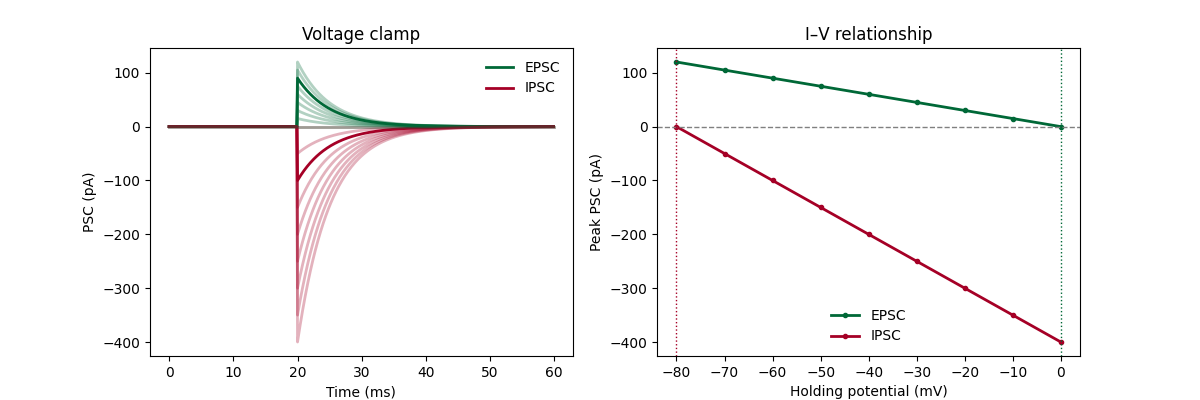

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -------- Panel A --------
for V in V_values:
    M = voltage_clamp_synapse(
            V_hold=V,
            json_file_name = synaptic_file_name
            )
    ax = axes[0]
    #print(f'V: {V}')
    if V == -60:
        ax.plot(M.t/b2.ms, M.IE[0]/b2.pA,
                color=syn_colors["E"], lw=2, label="EPSC")
        
        ax.plot(M.t/b2.ms, M.II[0]/b2.pA,
                color=syn_colors["I"], lw=2, label="IPSC")
        ax.legend(frameon=False)

    else:
        ax.plot(M.t/b2.ms, M.IE[0]/b2.pA,
                color=syn_colors["E"], lw=2, alpha = 0.3)
        
        ax.plot(M.t/b2.ms, M.II[0]/b2.pA,
                color=syn_colors["I"], lw=2, alpha = 0.3)
       
    
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("PSC (pA)")
    ax.set_title(f"Voltage clamp")

# -------- Panel B --------
ax = axes[1]

ax.plot(V_values, peak_IE, '.-',
        color=syn_colors["E"] , lw=2, label="EPSC")

ax.plot(V_values, peak_II, '.-',
        color=syn_colors["I"], lw=2, label="IPSC")

ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.axvline(0, color=syn_colors["E"], linestyle=':', lw=1)
ax.axvline(-80, color=syn_colors["I"], linestyle=':', lw=1)

ax.set_xlabel("Holding potential (mV)")
ax.set_ylabel("Peak PSC (pA)")
ax.set_title("I–V relationship")
ax.legend(frameon=False)

figs.append(fig)

In [8]:
save_figs(fig_path, fig_name, figs)